# Module 3: Multi-Head Attention

## Learning Objectives

- Understand why multiple attention heads help
- Learn how heads work in parallel
- Implement multi-head attention
- Analyze individual head behavior
- Visualize head specialization

**Duration**: ~20 minutes

## 1. The Core Idea

Instead of one attention computation, run **multiple** in parallel!

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, ..., \text{head}_h)W^O$$

where each head performs:

$$\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$

### Why Multiple Heads?

1. **Different representation subspaces**: Each head focuses on different aspects
2. **Parallel computation**: Process different patterns simultaneously
3. **Robustness**: Errors in one head don't kill the whole computation
4. **Rich representations**: Combine different perspectives


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)

print("Libraries loaded!")

Libraries loaded!


## 2. Single-Head vs Multi-Head

In [2]:
# Configuration
batch_size = 1
seq_len = 5
d_model = 8
num_heads = 4
d_k = d_model // num_heads  # 8 / 4 = 2

print("MULTI-HEAD ATTENTION SETUP")
print("="*60)
print(f"Model dimension (d_model): {d_model}")
print(f"Number of heads: {num_heads}")
print(f"Dimension per head (d_k): {d_k}")
print(f"Sequence length: {seq_len}")

print(f"\nDimension breakdown:")
print(f"  Input: (batch={batch_size}, seq_len={seq_len}, d_model={d_model})")
print(f"  Per head: (batch={batch_size}, seq_len={seq_len}, d_k={d_k})")
print(f"  {num_heads} heads in parallel")
print(f"  Concatenate: (batch={batch_size}, seq_len={seq_len}, d_model={d_model})")

MULTI-HEAD ATTENTION SETUP
Model dimension (d_model): 8
Number of heads: 4
Dimension per head (d_k): 2
Sequence length: 5

Dimension breakdown:
  Input: (batch=1, seq_len=5, d_model=8)
  Per head: (batch=1, seq_len=5, d_k=2)
  4 heads in parallel
  Concatenate: (batch=1, seq_len=5, d_model=8)


## 3. Step-by-Step Implementation

In [3]:
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention
    
    Formula:
        MultiHead(Q,K,V) = Concat(head_1,...,head_h)W^O
        head_i = Attention(QW_i^Q, KW_i^K, VW_i^V)
    """
    
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        # Linear projections for Q, K, V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        # Output projection
        self.W_o = nn.Linear(d_model, d_model)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, Q, K, V, mask=None):
        batch_size = Q.size(0)
        
        # Step 1: Project Q, K, V
        Q = self.W_q(Q)  # (batch, seq_len, d_model)
        K = self.W_k(K)
        V = self.W_v(V)
        
        # Step 2: Reshape for multi-head attention
        # (batch, seq_len, d_model) -> (batch, seq_len, num_heads, d_k) -> (batch, num_heads, seq_len, d_k)
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        # Step 3: Apply attention for each head
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.d_k)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)
        
        attn_output = torch.matmul(weights, V)
        # (batch, num_heads, seq_len, d_k)
        
        # Step 4: Concatenate heads
        attn_output = attn_output.transpose(1, 2).contiguous()
        # (batch, seq_len, num_heads, d_k)
        attn_output = attn_output.view(batch_size, -1, self.d_model)
        # (batch, seq_len, d_model)
        
        # Step 5: Final linear projection
        output = self.W_o(attn_output)
        
        return output, weights

# Test the implementation
d_model = 8
num_heads = 2
seq_len = 4

mha = MultiHeadAttention(d_model, num_heads)

X = torch.randn(1, seq_len, d_model)
output, weights = mha(X, X, X)

print(f"\nMulti-Head Attention Test:")
print(f"  Input shape: {X.shape}")
print(f"  Output shape: {output.shape}")
print(f"  Attention weights shape: {weights.shape}")
print(f"  ✓ Shapes look good!")


Multi-Head Attention Test:
  Input shape: torch.Size([1, 4, 8])
  Output shape: torch.Size([1, 4, 8])
  Attention weights shape: torch.Size([1, 2, 4, 4])
  ✓ Shapes look good!


## 4. Visualizing Attention Heads

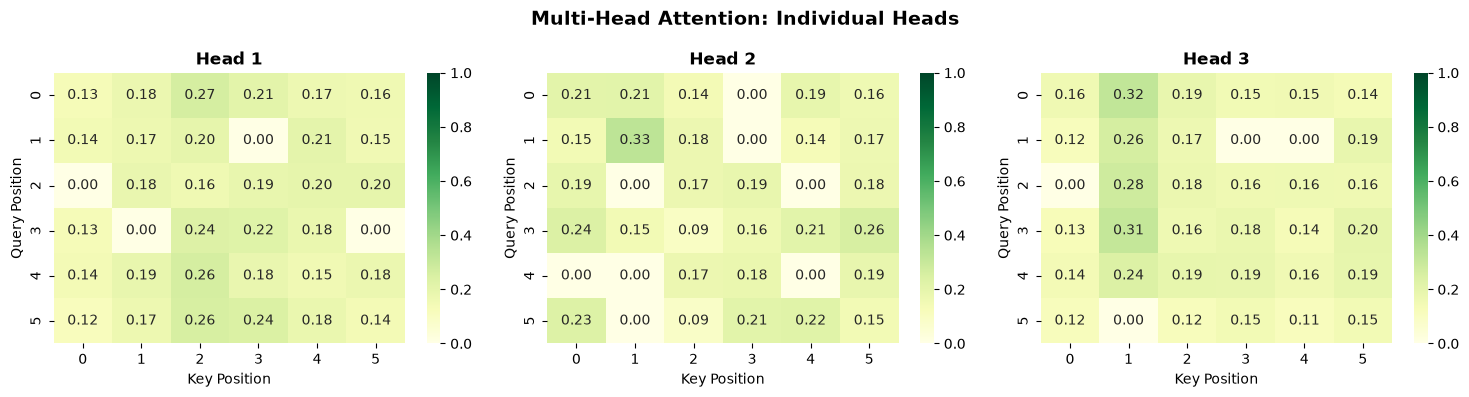

✓ Multi-head visualization saved


In [4]:
# Create a simple example to visualize
d_model = 12
num_heads = 3
seq_len = 6
batch_size = 1

mha = MultiHeadAttention(d_model, num_heads)
X = torch.randn(batch_size, seq_len, d_model)

output, weights = mha(X, X, X)

# Visualize each head
fig, axes = plt.subplots(1, num_heads, figsize=(15, 4))

for head_idx in range(num_heads):
    ax = axes[head_idx]
    head_weights = weights[0, head_idx].detach().numpy()
    
    sns.heatmap(head_weights, annot=True, fmt='.2f', cmap='YlGn', 
                vmin=0, vmax=1, ax=ax, cbar=True)
    ax.set_title(f'Head {head_idx + 1}', fontsize=12, weight='bold')
    ax.set_xlabel('Key Position')
    ax.set_ylabel('Query Position')

plt.suptitle('Multi-Head Attention: Individual Heads', fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig('multihead_attention.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Multi-head visualization saved")

## 5. Head Specialization Analysis

Different heads learn to focus on different patterns

In [5]:
# Analyze what each head is focusing on
print("HEAD SPECIALIZATION ANALYSIS")
print("="*60)

head_weights_cpu = weights[0].detach().numpy()

for head_idx in range(num_heads):
    head = head_weights_cpu[head_idx]
    
    print(f"\nHead {head_idx + 1}:")
    
    # Calculate attention entropy (how focused is this head)
    # High entropy = distributed attention
    # Low entropy = focused attention
    entropy = -np.sum(head * np.log(head + 1e-10))
    entropy_normalized = entropy / np.log(seq_len)  # Normalize to [0, 1]
    
    print(f"  Entropy (normalized): {entropy_normalized:.3f}")
    
    if entropy_normalized > 0.7:
        print(f"  Pattern: DISTRIBUTED (attends broadly)")
    elif entropy_normalized > 0.4:
        print(f"  Pattern: BALANCED (attends to multiple positions)")
    else:
        print(f"  Pattern: FOCUSED (attends to specific positions)")
    
    # Max attention weight per query
    max_weights = head.max(axis=1)
    print(f"  Average max attention: {max_weights.mean():.3f}")
    
    # Distance focus
    print(f"  Sample attention pattern (query 0): {head[0]}")

HEAD SPECIALIZATION ANALYSIS

Head 1:
  Entropy (normalized): 5.503
  Pattern: DISTRIBUTED (attends broadly)
  Average max attention: 0.237
  Sample attention pattern (query 0): [0.13474096 0.17723945 0.26537603 0.20960684 0.16743533 0.15671265]

Head 2:
  Entropy (normalized): 4.779
  Pattern: DISTRIBUTED (attends broadly)
  Average max attention: 0.236
  Sample attention pattern (query 0): [0.209061   0.21174069 0.14312643 0.         0.19426845 0.16084766]

Head 3:
  Entropy (normalized): 5.345
  Pattern: DISTRIBUTED (attends broadly)
  Average max attention: 0.260
  Sample attention pattern (query 0): [0.15750839 0.31892827 0.19139954 0.1518026  0.15325323 0.13821918]


## 6. Key Takeaways

### ✅ Multi-Head Attention

1. **Multiple parallel heads**: Each head runs independent attention
2. **Different subspaces**: Heads learn different representation spaces
3. **Concatenation**: Outputs combined back to d_model dimension
4. **Output projection**: Final linear transformation (W^O)

### 🎯 Why It Works

- **Complementary patterns**: Different heads capture different dependencies
- **Positional focus**: Some heads focus on nearby tokens, others on far tokens
- **Semantic focus**: Some heads focus on certain word types
- **Robustness**: No single head dominates the output

### 💡 Typical Head Counts

- **Small models**: 4-8 heads
- **Base models**: 12 heads
- **Large models**: 16-32 heads
- **More heads** generally = better but slower

### 🚀 Next Steps

1. **Notebook 4**: Full Transformer with multi-head attention
2. **Notebook 5**: Positional encoding
3. **Dashboard**: Experiment with head counts